In [20]:
# Cell 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [21]:
# Cell 2
#TODO ESG_E10 - Machine Learning
df = pd.read_csv("data/raw_esg_financial_data.csv")
df.head()

,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4
2,1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9
3,1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2
4,1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8


In [22]:
# Cell 3
#TODO ESG_E10 - Machine Learning
df.columns.tolist()

['CompanyID',
 'CompanyName',
 'Industry',
 'Region',
 'Year',
 'Revenue',
 'ProfitMargin',
 'MarketCap',
 'GrowthRate',
 'ESG_Overall',
 'ESG_Environmental',
 'ESG_Social',
 'ESG_Governance',
 'CarbonEmissions',
 'WaterUsage',
 'EnergyConsumption']

In [23]:
# Cell 4
#TODO ESG_E10 - Machine Learning
esg_cols = [col for col in df.columns if any(x in col.lower() for x in ['esg','environment','social','governance'])]

if 'ESG_Index' not in df.columns:
    df['ESG_Index'] = df[esg_cols].mean(axis=1)

target_cols = [c for c in df.columns if any(x in c.lower() for x in ['revenue','profit','income'])]

esg_cols, target_cols

(['ESG_Overall', 'ESG_Environmental', 'ESG_Social', 'ESG_Governance'],
 ['Revenue', 'ProfitMargin'])

In [24]:
# Cell 5
#TODO ESG_S11 - Build Model
if 'Revenue' in df.columns:
    target = 'Revenue'
else:
    target = target_cols[0]

features = esg_cols + ['ESG_Index']

X = df[features]
y = df[target]

X.head()

,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,ESG_Index
0,57.0,60.7,33.5,76.8,57.000
1,56.7,58.9,32.8,78.5,56.725
2,56.5,57.6,34.0,77.8,56.475
3,58.0,62.3,33.4,78.3,58.000
4,56.6,63.7,30.0,76.1,56.600


In [25]:
# Cell 6
#TODO ESG_S11 - Build Model
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape 

((8800, 5), (2200, 5))

In [26]:
# Cell 7
#TODO ESG_T15 - Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
# Cell 8
#TODO ESG_T15 - Linear Regression Model
y_pred = model.predict(X_test)

pred_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

pred_df.head(10) 

,Actual,Predicted
0,108029.1,6964.138044
1,697.3,1534.592191
2,602.9,3050.532686
3,1135.4,2225.209313
4,902.9,4886.521399
5,3956.8,7648.767039
6,1122.8,1846.761280
7,691.9,6162.632321
8,9455.2,4785.621120
9,9885.0,5751.908314


In [28]:
# Cell 9
#TODO ESG_E11 - Validation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

metrics = pd.DataFrame({
    'Metric':['MAE','MSE','RMSE','R2 Score'],
    'Value':[mae,mse,rmse,r2]
})

metrics

,Metric,Value
0,MAE,4.645052e+03
1,MSE,1.344779e+08
2,RMSE,1.159646e+04
3,R2 Score,3.098770e-02


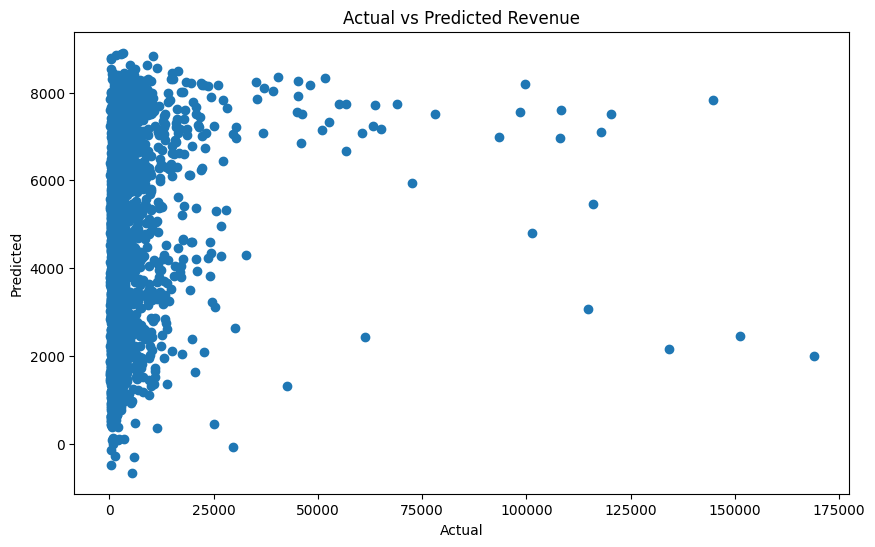

In [29]:
# Cell 10
#TODO ESG_S12 - Check Accuracy
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred)
plt.title("Actual vs Predicted Revenue")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show() 

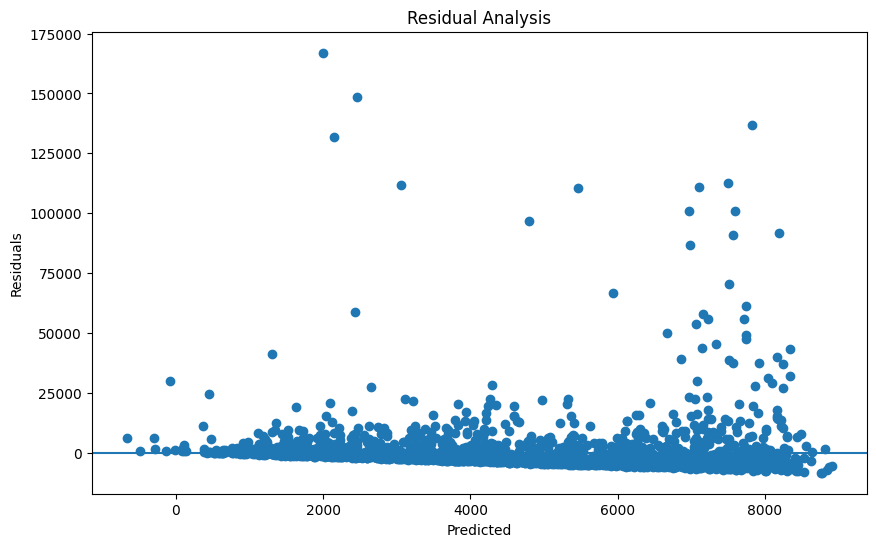

In [30]:
# Cell 11
#TODO ESG_S12 - Check Accuracy
residuals = y_test - y_pred

plt.figure(figsize=(10,6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.title("Residual Analysis")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show() 

In [31]:
# Cell 12
#TODO ESG_E11 - Validation
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
})

coef_df.sort_values(by='Coefficient', ascending=False) 

,Feature,Coefficient
1,ESG_Environmental,2792.160782
2,ESG_Social,2728.992478
3,ESG_Governance,2714.896105
4,ESG_Index,18.127162
0,ESG_Overall,-8163.540715


In [32]:
# Cell 13
#TODO ESG_S12 - Check Accuracy
print("Model Target:", target)
print("R2 Score:", round(r2,4))
print("RMSE:", round(rmse,2))
print("MAE:", round(mae,2))  

Model Target: Revenue
R2 Score: 0.031
RMSE: 11596.46
MAE: 4645.05


In [33]:
# Cell 14
#TODO ESG_E11 - Validation
if r2 > 0.7:
    print("Strong predictive model")
elif r2 > 0.4:
    print("Moderate predictive model")
else:
    print("Weak predictive model - ESG alone may not fully explain financial performance") 

Weak predictive model - ESG alone may not fully explain financial performance


In [34]:
import joblib

joblib.dump({
    "model": model,
    "features": X_train.columns.tolist()
}, "model.pkl")

['model.pkl']

In [35]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
